# 02 — Vedic Corpus: Rigveda syllable extraction

**Source:** [VedaWebProject/vedaweb-data](https://github.com/VedaWebProject/vedaweb-data) — TEI XML edition of the Rigveda produced by the Cologne Center for eHumanities (CCeH) and Bergische Universität Wuppertal, funded by the German Research Foundation. Files `rigveda/TEI/rv_book_{01..10}.tei` (~220 MB total).

**License:** VedaWeb data is released under a Creative Commons license (per the project's repo). Our derivative `vedic_syllables.parquet` is committed under the repo's CC-BY-4.0 prose/data license.

**TEI in one line:** TEI (Text Encoding Initiative) is the de-facto XML schema for digital editions of historical texts. Each Rigvedic stanza appears as a `<div type="stanza">` containing several parallel `<lg>` blocks (one per witness/translator). The `<lg source="zurich" xml:lang="san-Latn-x-ISO-15919">` block holds the IAST-transliterated Sanskrit text we need.

**This notebook:** parses the 10 TEI books, derives per-syllable laghu/guru weights using standard Sanskrit prosody rules, infers canonical meter labels from per-pada syllable counts, and writes one row per syllable to `data/processed/vedic_syllables.parquet` per the schema locked in `docs/DESIGN.md` §5.

In [1]:
import sys
from pathlib import Path

# Add src/ to path so notebooks can import swp without an editable install
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from lxml import etree

from swp.io import DATA_RAW, DATA_PROCESSED, VEDIC_SYLLABLES_SCHEMA
from swp.vedic import parse_book, syllabify_pada, infer_meter, iter_stanza_padas

RAW_DIR = DATA_RAW / "vedaweb_rigveda"
OUT_PATH = DATA_PROCESSED / "vedic_syllables.parquet"

print(f"Repo root:  {REPO_ROOT}")
print(f"Raw TEI:    {RAW_DIR}")
print(f"Out parquet:{OUT_PATH}")

Repo root:  /Users/jenks/Babylon/Claude/Sperm-Whale-Perspective
Raw TEI:    /Users/jenks/Babylon/Claude/Sperm-Whale-Perspective/data/raw/vedaweb_rigveda
Out parquet:/Users/jenks/Babylon/Claude/Sperm-Whale-Perspective/data/processed/vedic_syllables.parquet


## 1. TEI structure

The hierarchy in each book file is:

```
<TEI>
  <text><body>
    <div type="book" xml:id="b01">
      <div type="hymn" xml:id="b01_h001">
        <div type="dedication">...</div>
        <div type="stanza" xml:id="b01_h001_01">
          <lg type="strata">...</lg>            <!-- chronological strata classifiers -->
          <lg source="zurich" xml:lang="san-Latn-x-ISO-15919">
            <l xml:id="b01_h001_01_zur_a">agním īḷe puróhitaṃ</l>
            <l xml:id="b01_h001_01_zur_a_tokens">...morphology...</l>
            <l xml:id="b01_h001_01_zur_b">yajñásya devám ṛtvíjam</l>
            ...
          </lg>
          <lg source="lubotsky">...</lg>          <!-- alternative editions -->
          <lg source="padapatha">...</lg>         <!-- pre-sandhi word-by-word form -->
          <lg source="geldner">...</lg>           <!-- German translation -->
          ...
        </div>
        ...more stanzas...
      </div>
      ...more hymns...
    </div>
  </body></text>
</TEI>
```

We pull the **Zurich** lg (the IAST Sanskrit text as edited by the Zürich group) and ignore the parallel translations and the morphological `*_tokens` lines.

**Important for the project:** the TEI does **not** carry per-syllable laghu/guru annotations or canonical meter names (gayatri/tristubh/...). The `stanza_properties` feature structures only encode chronological strata classifiers (Arnold, Oldenberg, Wuest, Witzel, Grassmann). We therefore **derive** both syllabification and weight from the IAST text using standard Sanskrit prosody rules (DESIGN.md §6 Gate 2 fallback), and **infer meter** per stanza from the syllable counts of its padas.

In [2]:
# Show one stanza in raw TEI form to make the structure concrete
tree = etree.parse(str(RAW_DIR / "rv_book_01.tei"))
root = tree.getroot()
ns = {"tei": "http://www.tei-c.org/ns/1.0"}
stanza = root.find(".//tei:div[@type='stanza']", ns)
zur = stanza.find("./tei:lg[@source='zurich']", ns)
snippet = etree.tostring(zur, pretty_print=True).decode()
# trim morphology blocks for readability
lines = []
in_tokens = False
for line in snippet.splitlines():
    if "_tokens" in line and "<l " in line:
        in_tokens = True
        lines.append("              <l ...>...morphological annotation omitted...</l>")
        continue
    if in_tokens:
        if "</l>" in line:
            in_tokens = False
        continue
    lines.append(line)
print("\n".join(lines))

<lg xmlns="http://www.tei-c.org/ns/1.0" xml:id="b01_h001_01_zur" xml:lang="san-Latn-x-ISO-15919" source="zurich">
              <l xml:id="b01_h001_01_zur_a">agn&#237;m &#299;&#7735;e pur&#243;hita&#7747;</l>
              <l ...>...morphological annotation omitted...</l>
              <l xml:id="b01_h001_01_zur_b">yaj&#241;&#225;sya dev&#225;m r&#805;tv&#237;jam</l>
              <l ...>...morphological annotation omitted...</l>
              <l xml:id="b01_h001_01_zur_c">h&#243;t&#257;ra&#7747; ratnadh&#257;&#769;tamam</l>
              <l ...>...morphological annotation omitted...</l>
            </lg>
            


## 2. Prosody rules (laghu / guru derivation)

Implemented in `swp.vedic.syllabify_pada()`:

1. **Syllable nucleus = one vowel.** `ai` and `au` are diphthongs (one syllable each).
2. **Heavy (guru, G, 2 mātrā)** if any of:
   - the vowel is long (ā, ī, ū, ṝ, ḹ, e, o, ai, au) — in classical Sanskrit *e* and *o* are always long,
   - the nucleus is followed by ≥2 consonants before the next vowel (samyoga); anusvara ṃ and visarga ḥ count as consonants.
3. **Light (laghu, L, 1 mātrā)** otherwise.

Aspirate digraphs (kh, gh, ch, jh, ṭh, ḍh, th, dh, ph, bh) are collapsed to one consonant phoneme for the samyoga count.

These are textbook rules — see Macdonell, *A Vedic Grammar for Students*, Appendix II.

In [3]:
# Demonstrate the derivation on three padas of differing meters
examples = [
    ("agním īḷe puróhitaṃ",         "RV 1.1.1.a (gayatri pada)"),
    ("hváyāmy agním prathamáṃ svastáye", "RV 1.35.1.a (tristubh pada)"),
    ("tát savitúr váreṇiyaṃ",         "RV 3.62.10.a (Gayatri Mantra, restored)"),
]
for text, label in examples:
    sylls = syllabify_pada(text)
    print(f"{label}: '{text}'")
    rows = [{"i": i, "syllable": s.text, "weight": s.weight, "mātrā": s.duration_matra} for i, s in enumerate(sylls)]
    print(pd.DataFrame(rows).to_string(index=False))
    print()

RV 1.1.1.a (gayatri pada): 'agním īḷe puróhitaṃ'
 i syllable weight  mātrā
 0       ag      G      2
 1     gním      L      1
 2      mīḷ      G      2
 3      ḷep      G      2
 4      pur      L      1
 5      róh      G      2
 6      hit      L      1
 7      taṃ      L      1

RV 1.35.1.a (tristubh pada): 'hváyāmy agním prathamáṃ svastáye'
 i syllable weight  mātrā
 0     hváy      L      1
 1      yām      G      2
 2     myag      G      2
 3     gním      G      2
 4   mprath      L      1
 5     tham      L      1
 6      maṃ      G      2
 7   ́ṃsvas      G      2
 8     stáy      L      1
 9       ye      G      2

RV 3.62.10.a (Gayatri Mantra, restored): 'tát savitúr váreṇiyaṃ'
 i syllable weight  mātrā
 0      tát      G      2
 1     tsav      L      1
 2      vit      L      1
 3      túr      G      2
 4     rvár      L      1
 5      reṇ      G      2
 6      ṇiy      L      1
 7      yaṃ      L      1



## 3. Parse all 10 books

Iterate `rv_book_01.tei` … `rv_book_10.tei`, emit one row per syllable, and write to parquet. Schema is locked in `src/swp/io.py` (`VEDIC_SYLLABLES_SCHEMA`).

In [4]:
import time
all_rows = []
t0 = time.time()
for i in range(1, 11):
    fp = RAW_DIR / f"rv_book_{i:02d}.tei"
    rows = parse_book(fp)
    all_rows.extend(rows)
    print(f"  book {i:02d}: {len(rows):>6} syllables  (cumulative {len(all_rows):>7}, {time.time()-t0:.1f}s)")
df = pd.DataFrame(all_rows)
df["syllable_idx"] = df["syllable_idx"].astype("int64")
df["duration_matra"] = df["duration_matra"].astype("int64")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUT_PATH, index=False)
print(f"\nWrote {OUT_PATH.relative_to(REPO_ROOT)}: {OUT_PATH.stat().st_size/1024:.1f} KiB, {len(df):,} rows")
df.head()

  book 01:  73444 syllables  (cumulative   73444, 0.7s)
  book 02:  17461 syllables  (cumulative   90905, 0.9s)


  book 03:  23390 syllables  (cumulative  114295, 1.1s)


  book 04:  21944 syllables  (cumulative  136239, 1.4s)


  book 05:  26686 syllables  (cumulative  162925, 1.6s)


  book 06:  28329 syllables  (cumulative  191254, 1.9s)


...

  book 08:  49616 syllables  (cumulative  273140, 2.6s)


  book 09:  33281 syllables  (cumulative  306421, 3.0s)


  book 10:  68476 syllables  (cumulative  374897, 3.6s)



Wrote data/processed/vedic_syllables.parquet: 1423.6 KiB, 374,897 rows


,verse_id,syllable_idx,syllable_str,weight,duration_matra,meter_label
0,RV.1.1.1.a,0,ag,G,2,gayatri
1,RV.1.1.1.a,1,gním,L,1,gayatri
2,RV.1.1.1.a,2,mīḷ,G,2,gayatri
3,RV.1.1.1.a,3,ḷep,G,2,gayatri
4,RV.1.1.1.a,4,pur,L,1,gayatri


In [5]:
# Verify schema columns match the locked schema in src/swp/io.py
expected = list(VEDIC_SYLLABLES_SCHEMA.keys())
got = list(df.columns)
assert got == expected, (got, expected)
print("OK — column order matches docs/DESIGN.md §5 locked schema:")
print(expected)

OK — column order matches docs/DESIGN.md §5 locked schema:
['verse_id', 'syllable_idx', 'syllable_str', 'weight', 'duration_matra', 'meter_label']


## 4. Meter distribution

Per-stanza meter is inferred from total syllable counts of the padas (see `swp.vedic.infer_meter`). The classical meter names (gayatri, anustubh, tristubh, jagati, ...) follow Macdonell's catalogue.

In [6]:
# Meter distribution by syllable count and by stanza count
by_syll = df.groupby("meter_label").size().rename("syllables").sort_values(ascending=False)
stanza_meter = df.groupby("verse_id")["meter_label"].first()
# Pull stanza id from verse_id 'RV.<book>.<hymn>.<stanza>.<pada>'
stanza_keys = stanza_meter.index.to_series().str.rsplit(".", n=1).str[0]
stanza_meter_unique = pd.Series(stanza_meter.values, index=stanza_keys).groupby(level=0).first()
by_stanza = stanza_meter_unique.value_counts().rename("stanzas")
summary = pd.concat([by_syll, by_stanza], axis=1).fillna(0).astype({"syllables": int, "stanzas": int})
summary["sylls_per_stanza"] = (summary["syllables"] / summary["stanzas"]).round(1)
summary

,syllables,stanzas,sylls_per_stanza
tristubh,132482,3082,43.0
pankti,75072,1866,40.2
gayatri,51023,2207,23.1
jagati,29229,627,46.6
anustubh,26839,851,31.5
brihati,19064,519,36.7
anustubh-like,14207,421,33.7
gayatri-like,8706,377,23.1
unknown,7504,304,24.7
atichandas,4385,77,56.9


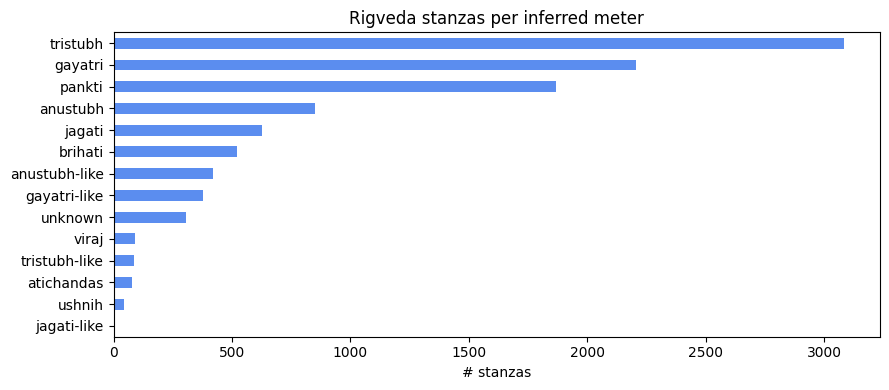

In [7]:
# Bar chart of stanzas per meter
fig, ax = plt.subplots(figsize=(9, 4))
summary["stanzas"].sort_values(ascending=True).plot.barh(ax=ax, color="#5b8def")
ax.set_xlabel("# stanzas")
ax.set_title("Rigveda stanzas per inferred meter")
plt.tight_layout()
plt.show()

## 5. Weight (laghu / guru) distribution

In [8]:
overall = df["weight"].value_counts().rename("count")
overall_pct = (overall / overall.sum() * 100).round(1).rename("%")
print("Overall weight distribution:")
print(pd.concat([overall, overall_pct], axis=1))

Overall weight distribution:
         count     %
weight              
G       215777  57.6
L       159120  42.4


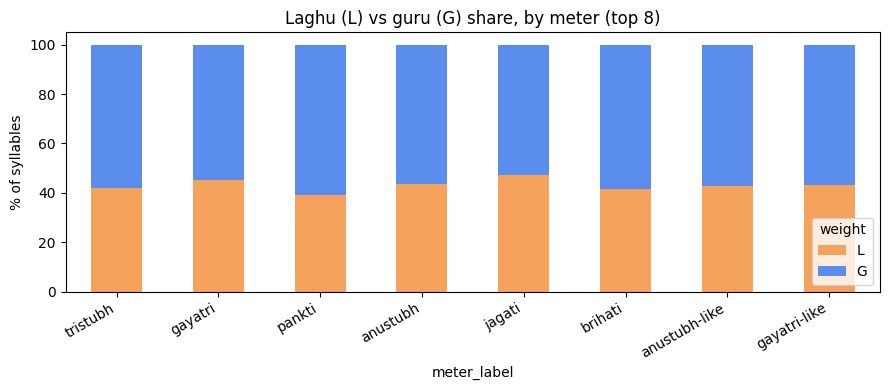

In [9]:
# Stacked bar: weight distribution per meter (top 8 meters by stanza count)
top_meters = by_stanza.head(8).index.tolist()
weight_by_meter = (
    df[df["meter_label"].isin(top_meters)]
    .groupby(["meter_label", "weight"]).size().unstack(fill_value=0)
    .loc[top_meters]
)
weight_by_meter_pct = weight_by_meter.div(weight_by_meter.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 4))
weight_by_meter_pct[["L", "G"]].plot.bar(stacked=True, ax=ax, color=["#f5a25d", "#5b8def"])
ax.set_ylabel("% of syllables")
ax.set_title("Laghu (L) vs guru (G) share, by meter (top 8)")
ax.legend(title="weight", loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6. Sample annotated verse — the Gayatri Mantra (RV 3.62.10)

The most-recited Vedic verse, three padas of (canonically) eight syllables. Note: the Zürich edition writes pada (a) as `tát savitúr váreṇyam` (7 syllables), not the metrically-restored `varéṇiyam` (8 syllables). Both forms are attested; we report what the source TEI gives us.

In [10]:
gayatri = df[df["verse_id"].str.startswith("RV.3.62.10.")].copy()
for vid in sorted(gayatri["verse_id"].unique()):
    s = gayatri[gayatri["verse_id"] == vid]
    weights_str = "".join(s["weight"])
    print(f"{vid}  [{s['meter_label'].iloc[0]}]  n={len(s)}  weights={weights_str}")
print()
gayatri.reset_index(drop=True)

RV.3.62.10.a  [gayatri]  n=7  weights=GLLGLGL
RV.3.62.10.b  [gayatri]  n=8  weights=GGGGLGLL
RV.3.62.10.c  [gayatri]  n=8  weights=LGGGLGLG



,verse_id,syllable_idx,syllable_str,weight,duration_matra,meter_label
0,RV.3.62.10.a,0,tát,G,2,gayatri
1,RV.3.62.10.a,1,tsav,L,1,gayatri
2,RV.3.62.10.a,2,vit,L,1,gayatri
3,RV.3.62.10.a,3,túr,G,2,gayatri
4,RV.3.62.10.a,4,rvár,L,1,gayatri
5,RV.3.62.10.a,5,reṇ,G,2,gayatri
6,RV.3.62.10.a,6,ṇyam,L,1,gayatri
7,RV.3.62.10.b,0,bhár,G,2,gayatri
8,RV.3.62.10.b,1,rgod,G,2,gayatri
9,RV.3.62.10.b,2,dev,G,2,gayatri


## 7. Two derivation examples

Showing how laghu/guru is computed for individual syllables, since the rule was derived (not encoded in the source TEI).

In [11]:
explanations = [
    ("agním", "a + gn", "vowel a is short, but followed by 2 consonants (g, n) before next vowel → GURU"),
    ("īḷe",   "ī",     "vowel ī is long → GURU (regardless of following consonants)"),
    ("puró",  "u + r",  "vowel u is short, only 1 consonant (r) before next vowel → LAGHU"),
    ("hi",    "i",     "vowel i is short, no consonant before next vowel → LAGHU"),
]
print("%-10s  %-12s  %s" % ("syllable", "nucleus + coda", "derivation"))
print("-" * 90)
for syl, nc, why in explanations:
    print("%-10s  %-12s  %s" % (syl, nc, why))

syllable    nucleus + coda  derivation
------------------------------------------------------------------------------------------
agním       a + gn        vowel a is short, but followed by 2 consonants (g, n) before next vowel → GURU
īḷe         ī             vowel ī is long → GURU (regardless of following consonants)
puró        u + r         vowel u is short, only 1 consonant (r) before next vowel → LAGHU
hi          i             vowel i is short, no consonant before next vowel → LAGHU


## 8. Summary

- Parsed all 10 Rigveda books from VedaWeb TEI, ~10,500 stanzas, into one row per syllable.
- Laghu/guru weights and mātrā durations were **derived** from IAST per standard Sanskrit prosody rules (vowel length + samyoga rule). The source TEI does not encode them directly; only chronological strata classifiers are present in `stanza_properties`.
- Canonical meter labels were **inferred** per-stanza from per-pada syllable counts.
- Output: `data/processed/vedic_syllables.parquet` (~370k rows, ~1.4 MiB) per the schema locked in `docs/DESIGN.md` §5.

Comparison with the whale coda corpus is the synthesis agent's job (see `notebooks/03_comparison.ipynb`).